In [ ]:
Q = np.random.rand(3,4)
K = np.random.rand(3,4)
V = np.random.rand(3,4)
output , weights = scaled_dot_product_attention(Q,K,V)
print("Attention Output", output)
print("Attention Weights:", weights)

Attention Output [[0.43340143 0.80131672 0.79231258 0.30858997]
 [0.43705459 0.80779245 0.79624761 0.31496988]
 [0.43582624 0.81009536 0.79738269 0.31882291]]
Attention Weights: [[0.32203263 0.33977534 0.33819203]
 [0.32351725 0.36188986 0.31459289]
 [0.31822078 0.36956679 0.31221243]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def softmax(x):
  exp_x = np.exp(x - np.max(x, axis = -1, keepdims=True))
  return exp_x / exp_x.sum(axis=-1,keepdims=True)

def scaled_dot_product_attention(Q,K,V, scaled=True):
  d_k = Q.shape[-1]
  scores = np.matmul(Q,K.T)
  if scaled:
    # Add a small epsilon to prevent division by zero in case d_k could theoretically be zero
    scores = scores / (np.sqrt(d_k) + 1e-8)
  weights = softmax(scores)
  output = np.matmul(weights ,  V)
  return output , weights

def multi_head_attention(Q , K , V , num_heads=1, scaled=True):
  d_model = Q.shape[-1]
  if d_model % num_heads != 0:
    raise ValueError(
        f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")
  depth = d_model // num_heads

  heads_output = []
  heads_weights_list = []

  for i in range(num_heads):
    Q_h = Q[:, i*depth:(i+1)*depth]
    K_h = K[:, i*depth:(i*depth+depth)]
    V_h = V[:, i*depth:(i*depth+depth)]

    out, weights = scaled_dot_product_attention(Q_h, K_h, V_h, scaled=scaled)
    heads_output.append(out)
    heads_weights_list.append(weights)

  concatenated_output = np.concatenate(heads_output, axis=-1)
  return concatenated_output, heads_weights_list

### Visualizing Scaled vs. Unscaled Multi-Head Attention


--- Visualizing Multi-Head Attention for 2 Heads ---


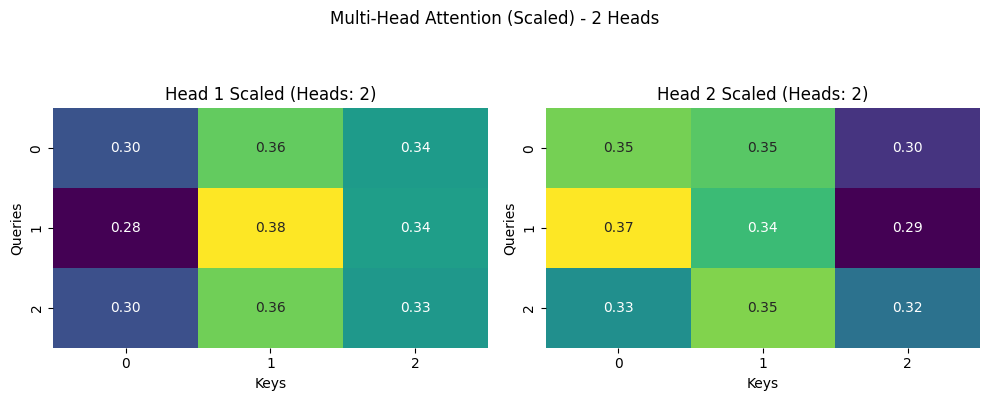

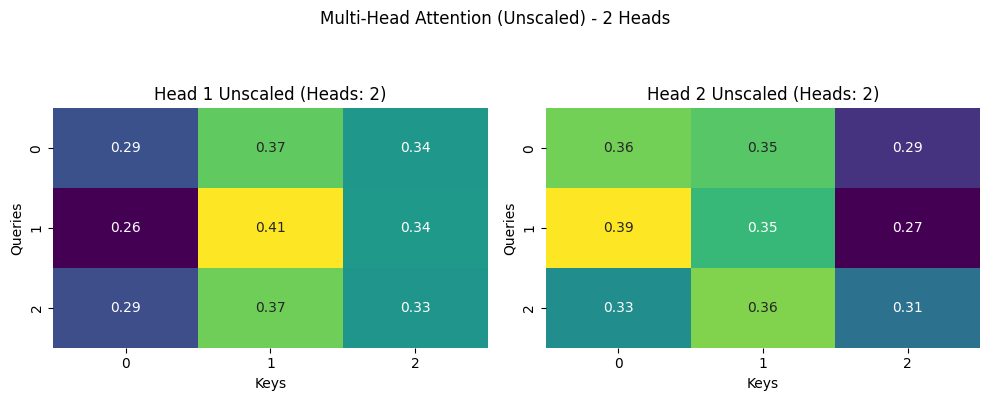


--- Visualizing Multi-Head Attention for 4 Heads ---


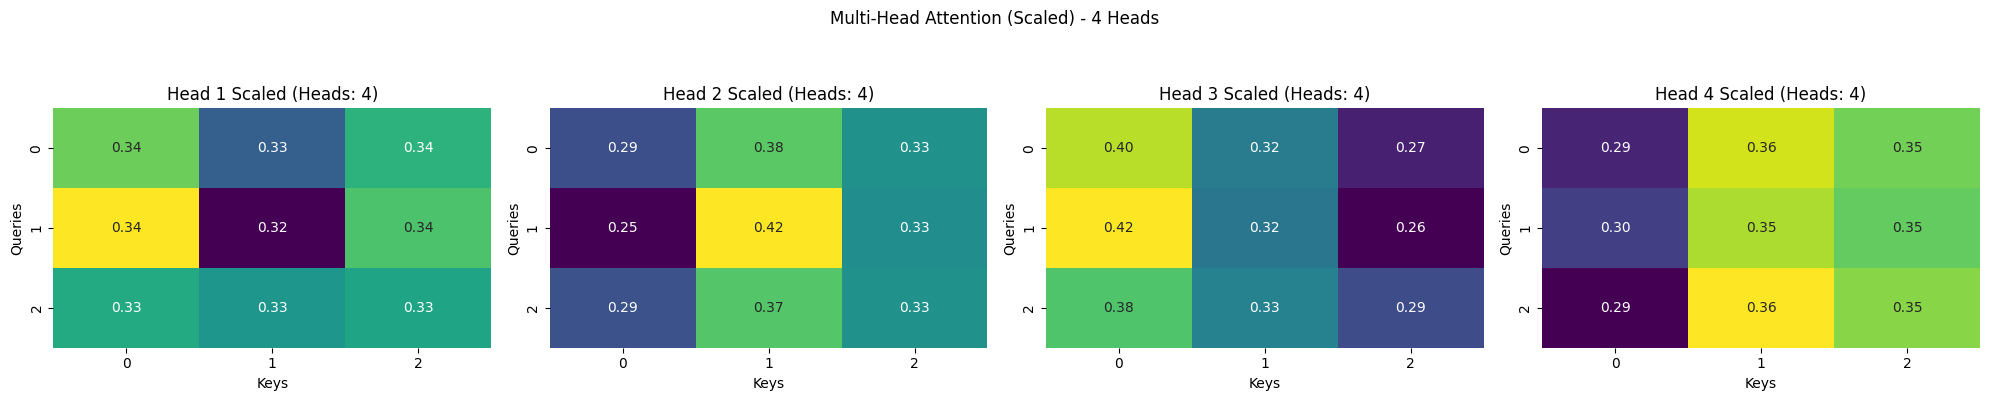

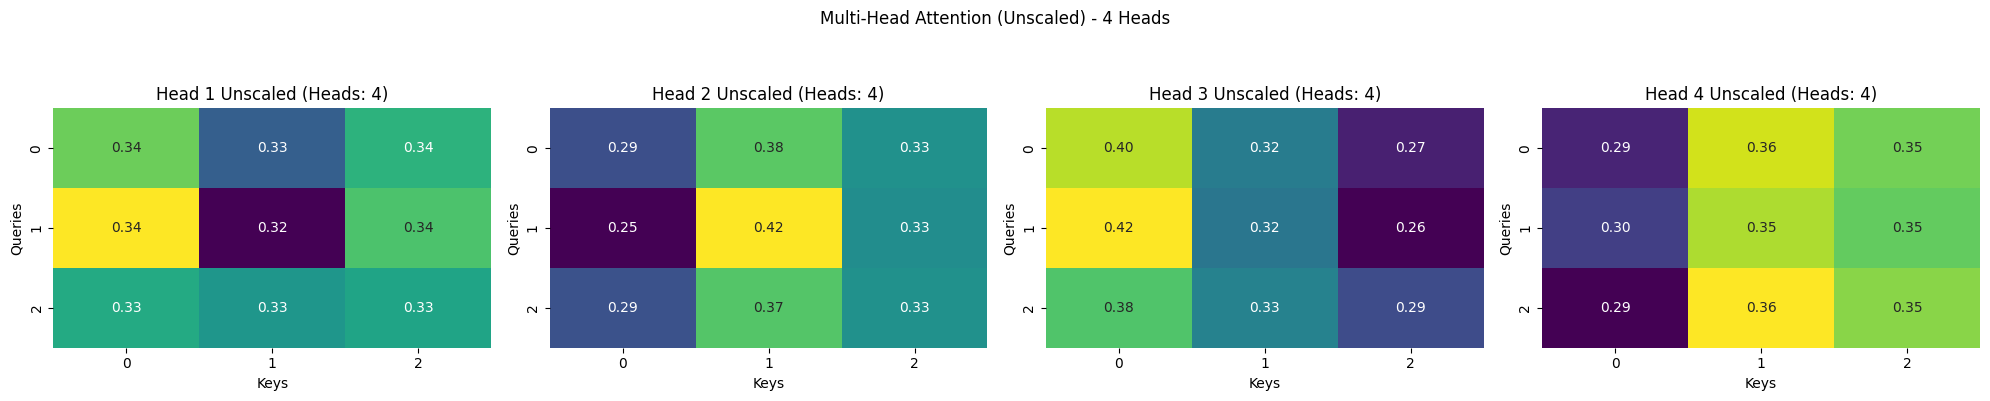

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported if not already in scope

Q = np.random.rand(3,4)
K = np.random.rand(3,4)
V = np.random.rand(3,4)

num_heads_list = [2, 4]

for num_heads in num_heads_list:
    print(f"\n--- Visualizing Multi-Head Attention for {num_heads} Heads ---")

    # Scaled Attention
    _, heads_weights_scaled = multi_head_attention(Q, K, V, num_heads=num_heads, scaled=True)
    fig_scaled, axes_scaled = plt.subplots(1, num_heads, figsize=(5 * num_heads, 4))
    if num_heads == 1: # Handle single head case for iteration
        axes_scaled = [axes_scaled]
    for i, weights in enumerate(heads_weights_scaled):
        sns.heatmap(weights, ax=axes_scaled[i], cmap='viridis', annot=True, fmt=".2f", cbar=False)
        axes_scaled[i].set_title(f'Head {i+1} Scaled (Heads: {num_heads})')
        axes_scaled[i].set_xlabel('Keys')
        axes_scaled[i].set_ylabel('Queries')
    plt.suptitle(f'Multi-Head Attention (Scaled) - {num_heads} Heads', y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Unscaled Attention
    _, heads_weights_unscaled = multi_head_attention(Q, K, V, num_heads=num_heads, scaled=False)
    fig_unscaled, axes_unscaled = plt.subplots(1, num_heads, figsize=(5 * num_heads, 4))
    if num_heads == 1:
        axes_unscaled = [axes_unscaled]
    for i, weights in enumerate(heads_weights_unscaled):
        sns.heatmap(weights, ax=axes_unscaled[i], cmap='viridis', annot=True, fmt=".2f", cbar=False)
        axes_unscaled[i].set_title(f'Head {i+1} Unscaled (Heads: {num_heads})')
        axes_unscaled[i].set_xlabel('Keys')
        axes_unscaled[i].set_ylabel('Queries')
    plt.suptitle(f'Multi-Head Attention (Unscaled) - {num_heads} Heads', y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### Observations: Scaled vs. Unscaled Multi-Head Attention

When comparing the heatmaps for scaled versus unscaled multi-head attention, you'll notice similar patterns to the single-head comparison:

*   **Scaled Attention:** The weights within each head are typically more distributed, showing varying degrees of attention across multiple keys. This allows each head to capture more nuanced relationships and contributes to a more stable learning process. The values are less prone to extremes.

*   **Unscaled Attention:** For each head, the attention weights tend to be much 'sharper'. You'll often see one or very few cells with values extremely close to 1, while others are near 0. This 'hard' attention can lead to unstable training, as the softmax function becomes saturated, causing vanishing gradients. It restricts the model's ability to learn complex, distributed dependencies across the input sequence within each head.

This behavior is consistent across different numbers of heads, illustrating why scaling is a crucial component of the Transformer architecture for stable and effective training.

In [ ]:
output = multi_head_attention(Q , K , V,num_heads=1 )
print("Output num_heads=1  ",output)

Output num_heads=1   (array([[0.43340143, 0.80131672, 0.79231258, 0.30858997],
       [0.43705459, 0.80779245, 0.79624761, 0.31496988],
       [0.43582624, 0.81009536, 0.79738269, 0.31882291]]), [array([[0.32203263, 0.33977534, 0.33819203],
       [0.32351725, 0.36188986, 0.31459289],
       [0.31822078, 0.36956679, 0.31221243]])])


In [ ]:
output = multi_head_attention(Q , K , V,num_heads=2 )
print("Output num_heads=2",output)
output = multi_head_attention(Q , K , V,num_heads=4 )
print("Output num_heads=4 ",output)

Output num_heads=2 (array([[0.44110079, 0.79260877, 0.79605794, 0.32221553],
       [0.44130966, 0.80504347, 0.79454675, 0.31434262],
       [0.43959808, 0.80802354, 0.79467967, 0.31473388]]), [array([[0.34909925, 0.31097322, 0.33992753],
       [0.33626622, 0.35293275, 0.31080103],
       [0.32913111, 0.36285799, 0.30801089]]), array([[0.30196238, 0.36569463, 0.33234299],
       [0.31681621, 0.35370495, 0.32947885],
       [0.31636647, 0.3545653 , 0.32906824]])])
Output num_heads=4  (array([[0.43724461, 0.78847467, 0.7964821 , 0.30795241],
       [0.43436718, 0.78351186, 0.79315503, 0.31181419],
       [0.43451635, 0.78814886, 0.7931162 , 0.31254739]]), [array([[0.33140457, 0.33843609, 0.33015934],
       [0.29871825, 0.42030484, 0.28097691],
       [0.30017751, 0.41680175, 0.28302074]]), array([[0.35737767, 0.29715228, 0.34547004],
       [0.36871305, 0.28060582, 0.35068113],
       [0.35811504, 0.29606579, 0.34581916]]), array([[0.29508382, 0.36967418, 0.335242  ],
       [0.3209180


--- Visualizing Attention Weights for 1 Heads ---


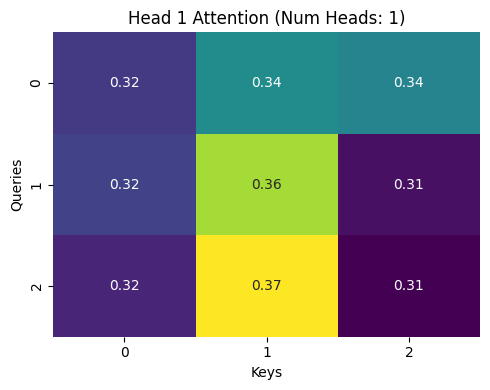


--- Visualizing Attention Weights for 2 Heads ---


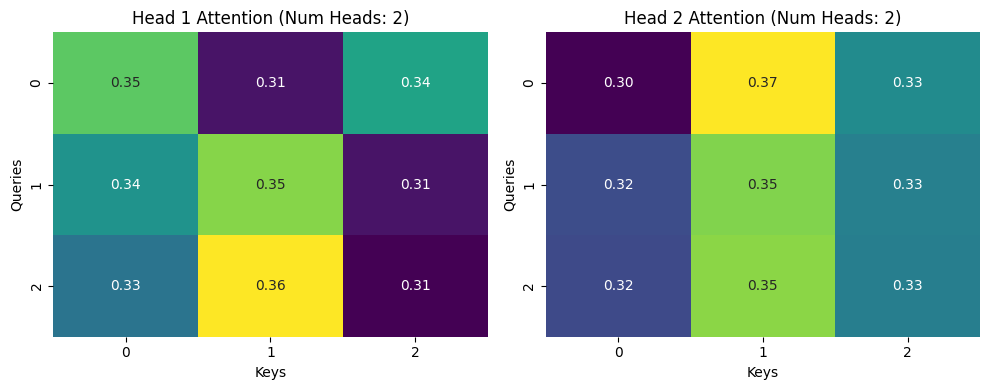


--- Visualizing Attention Weights for 4 Heads ---


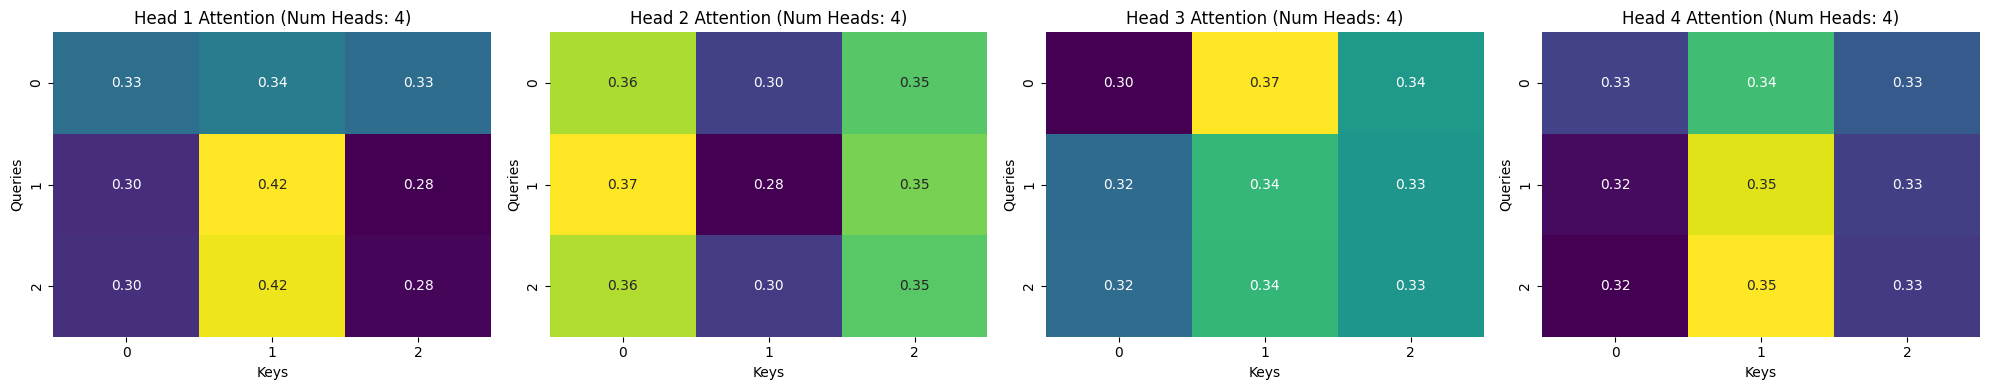

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_heads_list = [1, 2, 4]

for num_heads in num_heads_list:
    print(f"\n--- Visualizing Attention Weights for {num_heads} Heads ---")
    output, heads_weights = multi_head_attention(Q, K, V, num_heads=num_heads)

    # Plotting each head's attention weights
    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 4))
    if num_heads == 1:
        axes = [axes] # Make axes iterable for single plot case

    for i, weights in enumerate(heads_weights):
        sns.heatmap(weights, ax=axes[i], cmap='viridis', annot=True, fmt=".2f", cbar=False)
        axes[i].set_title(f'Head {i+1} Attention (Num Heads: {num_heads})')
        axes[i].set_xlabel('Keys')
        axes[i].set_ylabel('Queries')
    plt.tight_layout()
    plt.show()

### Visualizing Scaled vs. Unscaled Attention

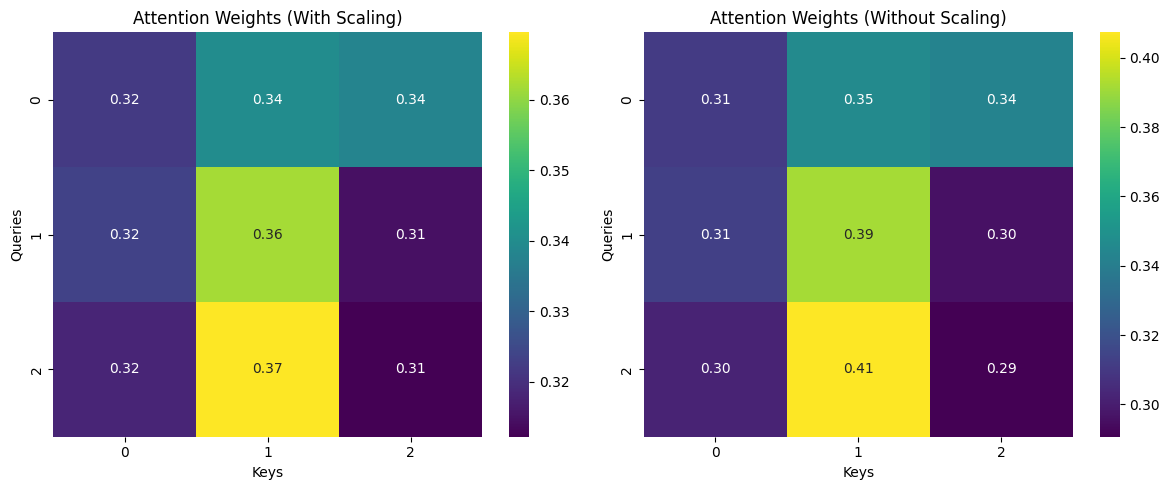

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate attention with scaling (default)
_, weights_scaled = scaled_dot_product_attention(Q, K, V, scaled=True)

# Generate attention without scaling
_, weights_unscaled = scaled_dot_product_attention(Q, K, V, scaled=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(weights_scaled, ax=axes[0], cmap='viridis', annot=True, fmt=".2f", cbar=True)
axes[0].set_title('Attention Weights (With Scaling)')
axes[0].set_xlabel('Keys')
axes[0].set_ylabel('Queries')

sns.heatmap(weights_unscaled, ax=axes[1], cmap='viridis', annot=True, fmt=".2f", cbar=True)
axes[1].set_title('Attention Weights (Without Scaling)')
axes[1].set_xlabel('Keys')
axes[1].set_ylabel('Queries')

plt.tight_layout()
plt.show()

### Difference: Scaled vs. Unscaled Attention Heatmaps

*   **With Scaling:** The attention weights are generally more distributed and less 'sharp'. This indicates that the query vector is paying attention to multiple key vectors to varying degrees, allowing for a more nuanced capture of relationships. The values are typically well-behaved, leading to stable gradients during training.

*   **Without Scaling:** The attention weights often appear much 'sharper', with one or very few cells having significantly higher values (closer to 1) while others are very low (closer to 0). This 'saturation' occurs because the unscaled dot products can be very large, pushing the softmax output to extremes. Such sharp distributions can lead to vanishing gradients, making training unstable and hindering the model's ability to learn complex, distributed dependencies.

### Random vs. Trained Weights

The heatmaps generated above (and previously) used randomly initialized `Q`, `K`, and `V` matrices. As explained earlier, these random weights produce chaotic and inconsistent patterns because the model hasn't learned any meaningful relationships yet.

If we were to visualize attention heatmaps with **trained weights**, you would observe structured and interpretable patterns. The heatmaps would show specific, high-attention regions where queries genuinely focus on relevant keys based on the context learned during training. For example, in a sentence, verbs might attend strongly to their subjects and objects, or pronouns might attend to the nouns they refer to. This contrasts sharply with the arbitrary patterns seen with random weights.

### What an Attention Heatmap Shows

An attention heatmap visually represents the *attention weights* computed during a self-attention mechanism. In the context of multi-headed self-attention, each head produces its own heatmap:

*   **Rows (Queries):** Each row typically corresponds to a query vector. In self-attention, queries are derived from the input sequence itself, meaning each row represents how much attention a particular element in the input sequence (the query) pays to other elements.
*   **Columns (Keys):** Each column typically corresponds to a key vector. Keys are also derived from the input sequence. Therefore, a column represents an element in the input sequence that the query elements are attending to.
*   **Color Intensity:** The color intensity in each cell `(i, j)` indicates the attention weight that the `i`-th query assigns to the `j`-th key. A brighter or more intense color (depending on the colormap) signifies a higher attention weight, meaning the `i`-th input element pays more attention to the `j`-th input element. Conversely, a darker or less intense color means less attention.

In essence, the heatmap allows us to visualize how different parts of an input sequence relate to each other, revealing which elements are considered most relevant when processing a specific element.

### Without Scaling vs. With Scaling in Self-Attention

**Scaling** in the scaled dot-product attention mechanism refers to dividing the dot product of queries and keys by the square root of the dimension of the key vectors (`d_k`). So, the formula is `softmax(Q * K^T / sqrt(d_k)) * V`.

*   **Without Scaling:** If the dot products (`Q * K^T`) are not scaled, their magnitudes can become very large, especially with high-dimensional key vectors (`d_k`). When these large values are passed through the softmax function, the gradients can become extremely small (saturating the softmax), leading to a very 'sharp' distribution where one attention weight is very close to 1 and all others are very close to 0. This makes the model difficult to train as the gradients tend to vanish.
    *   **Effect:** Unstable training, slow convergence, difficulty in learning nuanced relationships, and a tendency for attention to be overly focused on a single token.

*   **With Scaling:** Dividing by `sqrt(d_k)` reduces the magnitude of the dot products. This helps in keeping the variance of the dot products consistent, regardless of the dimension `d_k`. When these scaled values are passed through the softmax function, the gradients are more stable and less prone to vanishing or exploding.
    *   **Effect:** More stable training, faster convergence, allowing the model to learn more diverse and distributed attention patterns, and better exploration of relationships between different tokens. It prevents the softmax from becoming saturated and ensures that the attention weights are well-behaved.

### Random vs. Trained Weights

The distinction between attention heatmaps generated with random weights versus trained weights is fundamental to understanding the learning process of a Transformer model.

*   **Random Weights:**
    *   **Initial State:** At the beginning of training, the model's weights (including those in the query, key, and value linear layers) are typically initialized randomly. This means that the relationships they compute between different tokens are arbitrary and lack any meaningful semantic or syntactic understanding.
    *   **Heatmap Appearance:** An attention heatmap generated with random weights will show chaotic and inconsistent patterns. There will be no discernible structure or logical connections between queries and keys. The attention distribution for each query will be essentially random, not reflecting any true importance or relevance.
    *   **Purpose:** The primary purpose of random weights is to break symmetry and provide a starting point for the optimization process. They are not expected to produce useful results.

*   **Trained Weights:**
    *   **Learned State:** As the model undergoes training on a large dataset, it adjusts its weights through backpropagation and gradient descent. The goal is to minimize a loss function, which guides the model to learn meaningful patterns and relationships within the data.
    *   **Heatmap Appearance:** An attention heatmap generated with trained weights will reveal structured and interpretable patterns. The model learns to assign higher attention weights to tokens that are genuinely relevant to a given query. For example:
        *   In a sentence like "The cat sat on the mat," when the model processes "sat," it might learn to attend strongly to "cat" and "mat" because these words are semantically linked to the action of sitting.
        *   In coreference resolution, a pronoun like "it" might attend to the noun it refers to.
        *   In translation, words in the target language might attend to their corresponding words in the source language.
    *   **Purpose:** Trained weights enable the model to effectively capture context, dependencies, and semantic relationships within the input, which is crucial for its performance on various natural language processing tasks.